# Left-Right Check

This notebook aims to certify that avgWTP_left and avgWTP_right are consistently defined through the pipelines. Points of concern are within:

1. Empirical distributinos
2. Generate fixations
3. Drift function

## Checking Empirical Distributions

In [ ]:
# %load -r 236-242 simulation.py
if legend is None:
    legend = {"left": {1}, "right": {2}, "transition": {0}, "blank_fixation": {3}}
Lset = set(legend.get("left", set()))
Rset = set(legend.get("right", set()))
Tset = set(legend.get("transition", {0}))   # codes that behave like 0 (transitions)
Bset = set(legend.get("blank_fixation", {3}))   # codes that behave like 3 (do NOT count as transitions after first fix)
ignore_set = set(legend.get("ignore", set()))

The above is the default legend that is used in empirical distributions. Whenever any `empirical_distributions` object is generated, I typically define this in the cell just to make sure that the object is properly representing the fixations. Note that left is 1 and right is 2 here.

In [ ]:
# %load -r 257-258,315,327-330,379 simulation.py
def closest_bin(x, bins):
    return min(bins, key=lambda b: abs(x - b))

# ...

for row in trial_iter:
    # ...
    v_left  = float(get_vL(row))
    v_right = float(get_vR(row))
    sv_lookup = {"L": v_left - v_right, "R": v_right - v_left}

    # ...
    b = closest_bin(sv_lookup[lab], valueDiffs)

Here we see left relative values as being left - right, and right being right - left. In practice the closest_bin function should never have to rely on a close bin if valueDiffs are properly defined and passed to the function. In my exploratory notebooks, this is the case.

Since everything from empirical distributions was already verified in eum_empirical_distributions_check.ipynb, we must take the above as factual, and following steps should remain consistent.

## Checking Generate Fixations

In [ ]:
# %load -r 407 simulation.py
def generate_fixations(dt, relative_value_difference, empirical_distributions, max_duration_s=30.0, rng=None):

When calling generate fixation, the relative value difference is standardly defined as avgWTP_left - avgWTP_right. The following logic should be consistent with it as the direction of the first fixation is assigned.

In [ ]:
# %load -r 461-462,465 simulation.py
probLeftFirst = float(empirical_distributions['probFixLeftFirst'])
left_first = rng.random() < probLeftFirst

rel_val_for_first = relative_value_difference if left_first else -relative_value_difference

Above, we see left_first being assigned through the empirical distributions object passed to the function. Additionally, the relative value for the first fixation is swapped depending on the direction of the first fixation. If it is left, then nothing changes and the first relative value is the relative value difference passed to it: avgWTP_left - avgWTP_right. If it is right, then the difference is made negative.

In [ ]:
# %load -r 477,482-483,493,510 simulation.py
code = 1 if left_first else 2

# ...
# After processing the first fixation to prepare for the second fixation
current_side_code = 2 if code == 1 else 1
abs_val = abs(relative_value_difference)

# ...
while global_time < max_duration_s:
    # After a fixation is processed, switch sides
    current_side_code = 2 if current_side_code == 1 else 1

In order, the code above assigns a code, 1 being left, and 2 being right, to the first fixation conditional on left_first. Then, the code swaps to represent the subject looking at the opposite stimulus. Continuously for the next 30 seconds, switching occurs. Importantly, fixation durations are pooled for both relative value differences (positive and negative).

In [ ]:
# %load -r 450-459,489,493,503 simulation.py
def pooled_fixation_durations(fixation_dict, abs_val):
    pool = []
    # exact match
    if abs_val in fixation_dict: pool.extend(fixation_dict[abs_val])
    if -abs_val in fixation_dict: pool.extend(fixation_dict[-abs_val])
    # nearest-key fallback if pool empty
    if not len(pool):
        k1 = min(fixation_dict.keys(), key=lambda kk: abs(abs(kk) - abs_val))
        pool.extend(fixation_dict[k1])
    return np.asarray(pool)

# ...

pooled2 = pooled_fixation_durations(fix2, abs_val)

# ...
# After processing the first fixation to prepare for the second fixation
while global_time < max_duration_s:

    # ...
    # For each fixation
    fdur = rng.choice(pooled2)

To be more consistent with the theoretical approach, I should reconstruct using a pooling of near bins instead of the opposite bin. Before doing so, I should check with empirical distributions to see the average duration within near bins in the middle fixations.

## Checking Drift Function

In [ ]:
# %load -r 10-20 simulation.py
def drift_function(x, t, avgWTP_left, avgWTP_right, fixation):
    fixation_index = min(int(t/dt), len(fixation)-1)
    current_fixation = fixation[fixation_index]
    if current_fixation == 0: # saccade
        drift_val = 0
    elif current_fixation == 1: # left
        drift_val = drift * (avgWTP_left - avgWTP_right * theta)
    else: # right
        drift_val = drift * (avgWTP_left * theta - avgWTP_right)
    
    return np.ones_like(x) * drift_val

Although I custom define drift functions and models in a grid search due to the specific needs of PyDDM's parameter system, this is the default drift function that I use. We see that when a fixation is 1, this represents left, just like the empirical distributions legend. When the fixation is 2, this represents right. The only difference from this drift function to the legend is that blank fixations are removed and replaced with transitions. The motivating theory behind this is that the blank fixation-transition distinction was used during the experiment to track when participants would slightly deviate from a stimulus towards the center, but not crossing over to the other side through the middle of the two objects. If a blank fixation is not reported, then the time spent looking at the stimulus and darting away from it is combined with the time spent looking back at the stimulus a second time as one time block. Careful attention to the reported data shows that not all such activity was cleaned because there are instances of a participant looking back at the same object after making a blank fixation. However, for the intent of the aDDM simulation, this need not be considered.

Through an audit of existing code, I have confirmed that the left/right assignment is done correctly according to empirical distributions. However, the pooled fixations used in generate fixation may pose an issue. Instead, I will try to implement a fix by interpolating from the nearest bins.

## Fixing Pooling in Generate Fixations

Implementing interpolation over pooling should be motivated by a quantifiable bias. From rvd_check.ipynb, I know that there is a possibility for this to occur, so I will first graph the durations by bin (particularly extreme ones).

### Loading data

In [15]:
from ast import literal_eval
from simulation import get_corrected_empirical_distributions
import pandas as pd
import numpy as np

df_raw = pd.read_csv('1ms_trial_data.csv')
df_raw['RT'] = df_raw['RT']*1000 # adjustment for RT
df_raw['fixation'] = df_raw['fixation'].apply(literal_eval)

to_drop = pd.read_csv("dropped_trials.csv").rename(columns={"parcode": "sub_id"})

df = df_raw.loc[
    ~df_raw.set_index(["sub_id", "trial"]).index.isin(
        to_drop.set_index(["sub_id", "trial"]).index
    )
    & (~df_raw["hidden"])
]

value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'

empirical_distributions = get_corrected_empirical_distributions(
    df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=0.9
)

### Plotting pooling frequencies

In [2]:
import matplotlib.pyplot as plt

def overlay_histograms(
    data_a,
    data_b,
    *,
    bins=50,
    label_a="A",
    label_b="B",
    alpha=0.6,
    density=False
):
    """
    Overlay two histograms for visual comparison.

    Parameters
    ----------
    data_a, data_b : array-like
        The two samples to compare.
    bins : int or sequence
        Number of histogram bins.
    density : bool
        If True, normalize histograms to integrate to 1.
    """
    data_a = np.asarray(data_a)
    data_b = np.asarray(data_b)

    plt.figure()
    plt.hist(data_a, bins=bins, alpha=alpha, label=label_a, density=density)
    plt.hist(data_b, bins=bins, alpha=alpha, label=label_b, density=density)

    plt.xlabel("Value")
    plt.ylabel("Density" if density else "Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

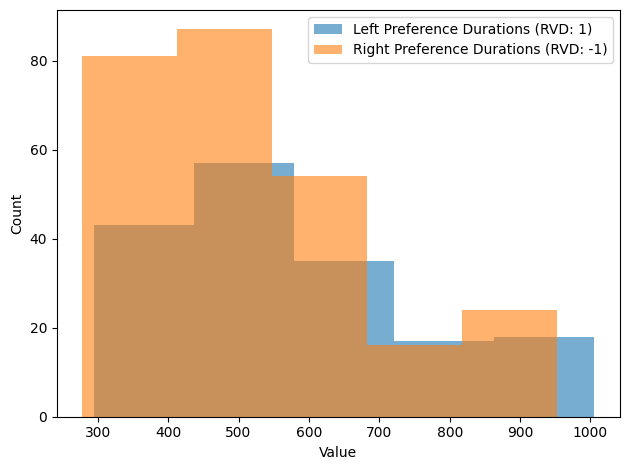

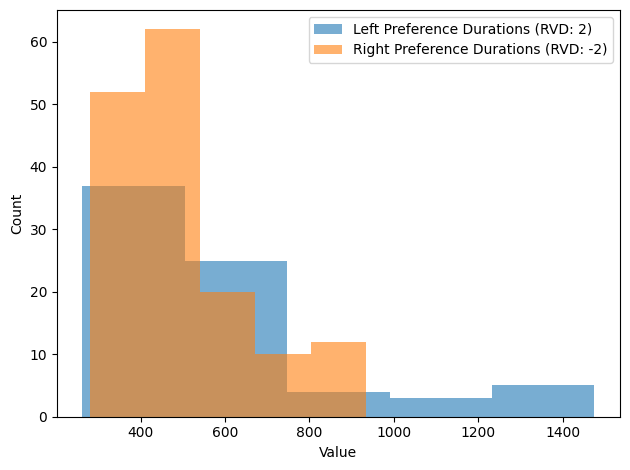

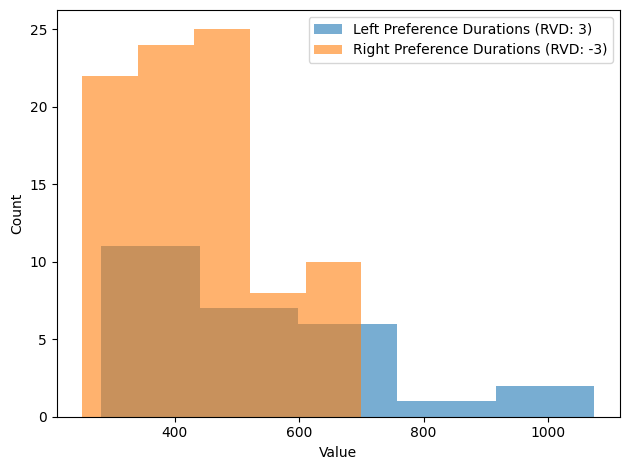

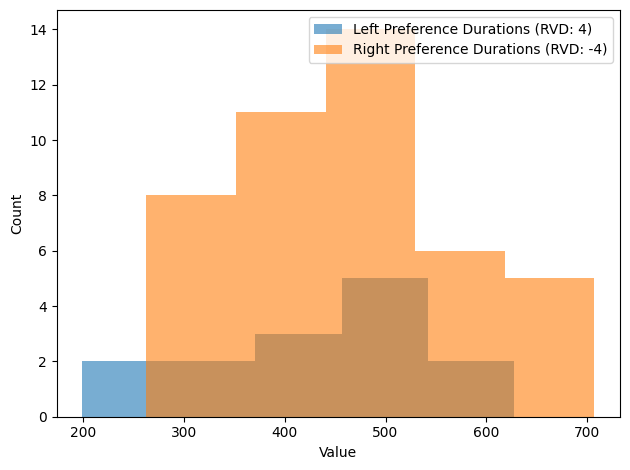

In [3]:
for i in range(1, 5):
    overlay_histograms(
        empirical_distributions['fixations'][2][i],
        empirical_distributions['fixations'][2][-i],
        bins=5,
        label_a=f"Left Preference Durations (RVD: {i})",
        label_b=f"Right Preference Durations (RVD: {-i})",
        density=False
    )

Pooling clearly shows a difference in fixation durations based on relative value difference. As from eum_empirical_distributions_check.ipynb, there tend to be more middle fixations towards the right due to a preference for left first fixations. Thus, pooling would disproportionately sample from right fixations, which have (significantly?) distributions.

### Plotting interpolation frequencies

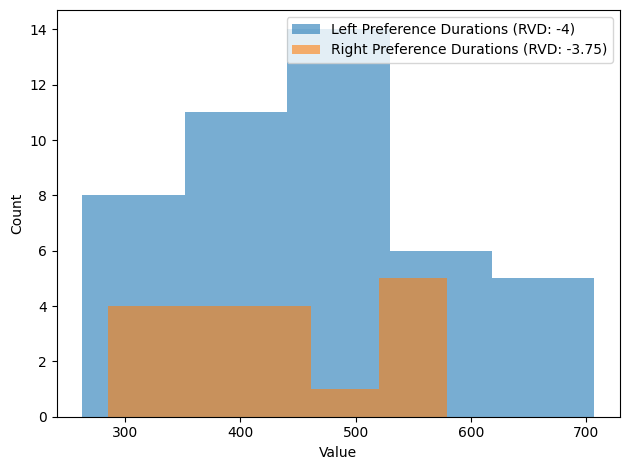

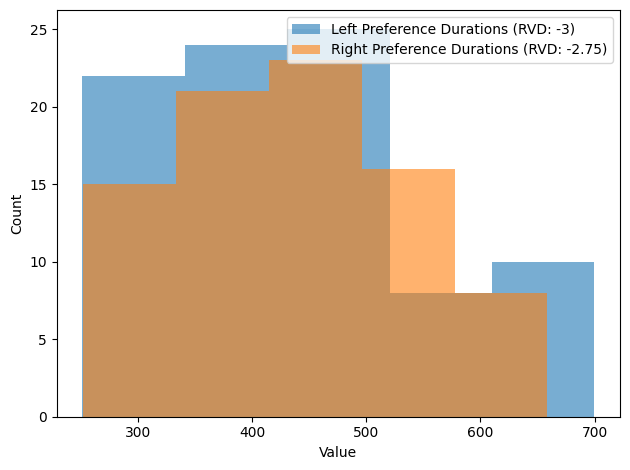

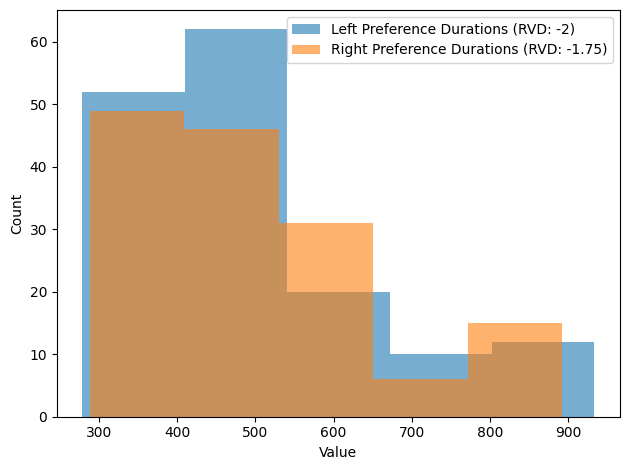

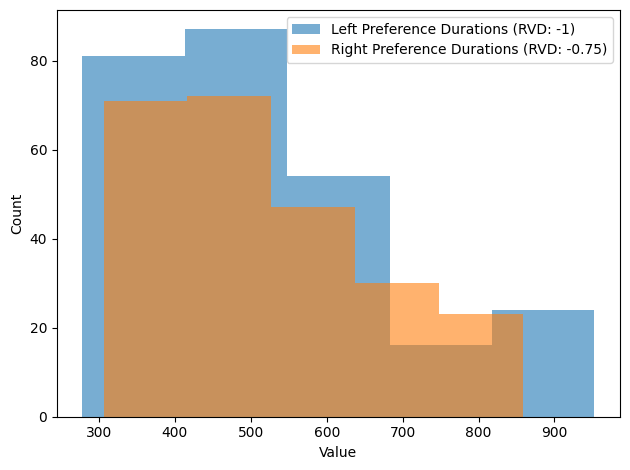

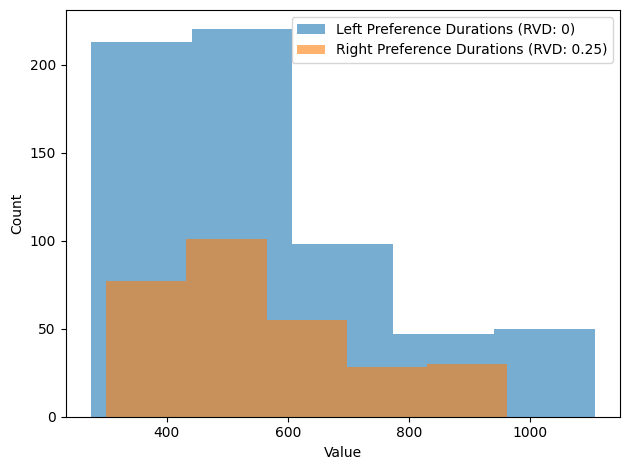

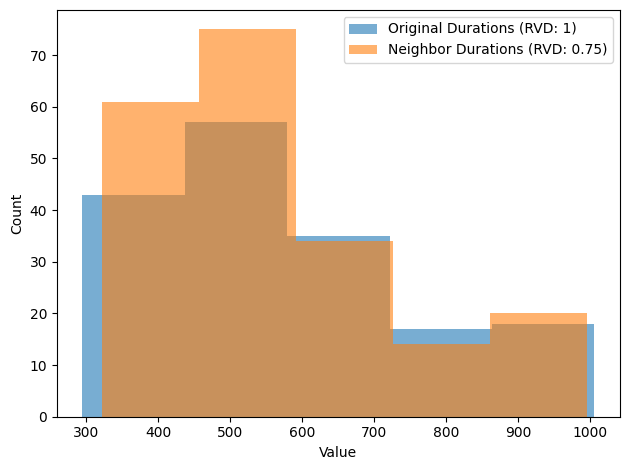

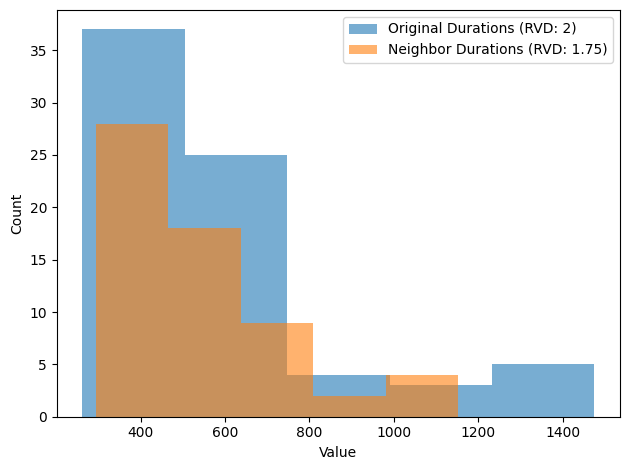

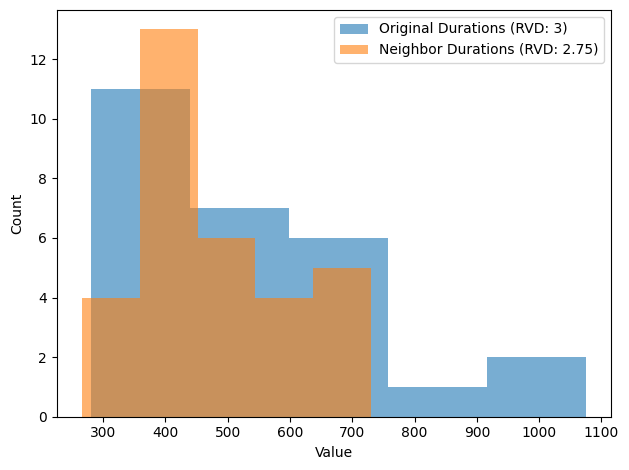

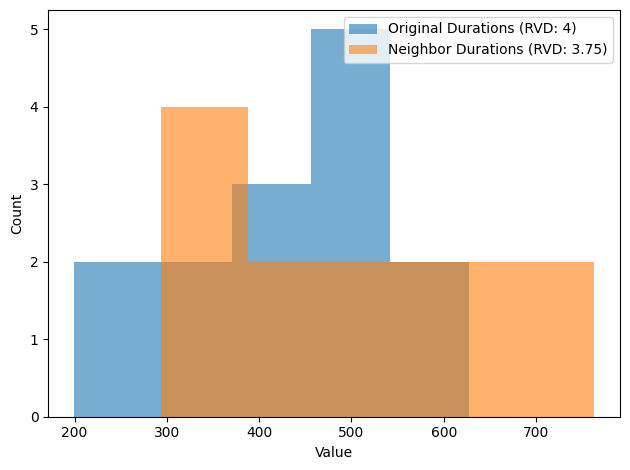

In [4]:
for i in range(-4, 5):
    if i <= 0:
        overlay_histograms(
            empirical_distributions['fixations'][2][i],
            empirical_distributions['fixations'][2][i+0.25],
            bins=5,
            label_a=f"Left Preference Durations (RVD: {i})",
            label_b=f"Right Preference Durations (RVD: {i+0.25})",
            density=False
        )
    else:
        overlay_histograms(
            empirical_distributions['fixations'][2][i],
            empirical_distributions['fixations'][2][i-0.25],
            bins=5,
            label_a=f"Original Durations (RVD: {i})",
            label_b=f"Neighbor Durations (RVD: {i-0.25})",
            density=False
        )

### Simulating fixations

In [16]:
def interpolate_generate_fixations(dt, relative_value_difference, empirical_distributions,
                       max_duration_s=30.0, rng=None):
    """
    Return a tuple of fixation codes sampled on a fixed `dt` grid.

    IMPORTANT:
    - `dt` must match the model's dt used by the DDM solver.
    - One element in the returned tuple represents the interval [i*dt, (i+1)*dt).
    """

    if dt <= 0:
        raise ValueError("dt must be a positive time step in seconds")
    if rng is None:
        rng = np.random.default_rng()

    try:
        # ---------- helpers ----------
        def to_seconds(arr):
            arr = np.asarray(arr)
            return arr / 1000.0

        def fix_to_seconds(fix_dict):
            return {k: to_seconds(v) for k, v in fix_dict.items()}

        def nearest_key(dct, key):
            return min(dct.keys(), key=lambda kk: abs(kk - key))

        # ---------- normalize inputs ----------
        latencies_s   = to_seconds(empirical_distributions['latencies'])
        transitions_s = to_seconds(empirical_distributions['transitions'])

        fix1 = fix_to_seconds(empirical_distributions['fixations'][1])
        fix2 = fix_to_seconds(empirical_distributions['fixations'][2])

        if len(transitions_s) == 0:
            raise ValueError("Empty transition distribution.")

        # ---------- choose first fixation side ----------
        probLeftFirst = float(empirical_distributions['probFixLeftFirst'])
        left_first = rng.random() < probLeftFirst

        rel_val_for_first = (
            relative_value_difference if left_first
            else -relative_value_difference
        )

        # ---------- timeline ----------
        events = []
        global_time = 0.0

        # Initial latency
        latency = rng.choice(latencies_s)
        events.append((global_time, global_time + latency, 0))
        global_time += latency

        # ---------- first fixation (no interpolation) ----------
        if rel_val_for_first not in fix1:
            rel_val_for_first = nearest_key(fix1, rel_val_for_first)

        first_fix_dur = rng.choice(fix1[rel_val_for_first])
        code = 1 if left_first else 2
        events.append((global_time, global_time + first_fix_dur, code))
        global_time += first_fix_dur

        current_side_code = 2 if code == 1 else 1

        # ---------- subsequent fixation interpolation ----------
        rvd = relative_value_difference
        step = 0.25  # matches your empirical binning

        if rvd <= 0:
            rvd_neighbor = rvd + step
        else:
            rvd_neighbor = rvd - step

        # Fetch bins with graceful fallback
        if rvd not in fix2:
            rvd = nearest_key(fix2, rvd)
        if rvd_neighbor not in fix2:
            rvd_neighbor = nearest_key(fix2, rvd_neighbor)

        durs_main = fix2.get(rvd, [])
        durs_neigh = fix2.get(rvd_neighbor, [])

        if len(durs_main) == 0 and len(durs_neigh) == 0:
            raise ValueError("No fixation durations available after interpolation.")

        # Simple interpolation = mixture
        subsequent_durations = np.concatenate([durs_main, durs_neigh])

        # ---------- generate alternations ----------
        while global_time < max_duration_s:
            # Transition
            tdur = rng.choice(transitions_s)
            start = global_time
            end = min(global_time + tdur, max_duration_s)
            events.append((start, end, 0))
            global_time = end
            if global_time >= max_duration_s:
                break

            # Fixation
            fdur = rng.choice(subsequent_durations)
            start = global_time
            end = min(global_time + fdur, max_duration_s)
            events.append((start, end, current_side_code))
            global_time = end

            current_side_code = 2 if current_side_code == 1 else 1

        # ---------- bin to dt grid ----------
        num_bins = int(np.floor(max_duration_s / dt))
        fixation_sequence = []

        e_idx = 0
        for i in range(num_bins):
            t = i * dt
            while e_idx < len(events) and not (events[e_idx][0] <= t < events[e_idx][1]):
                e_idx += 1
            if e_idx < len(events):
                fixation_sequence.append(events[e_idx][2])
            else:
                fixation_sequence.append(0)

        return tuple(fixation_sequence)

    except Exception as e:
        raise RuntimeError(
            f"generate_fixations failed for dt={dt}, rvd={relative_value_difference}"
        ) from e


In [17]:
from simulation import simulate, generate_fixations
import pyddm

dt = 0.01
seed = 42
model_conditions = {'drift_rate': 0.7, 'theta': 0.5, 'noise': 0.53}

trials = df.loc[df['trial'] % 2 == 1].loc[:, ['avgWTP_left', 'avgWTP_right']]
trials['fixation'] = None

rng = np.random.default_rng(42)
trials_dict = []
for idx, r in trials.iterrows():
    fx = generate_fixations(
        dt, 
        r.avgWTP_left - r.avgWTP_right, 
        empirical_distributions,
        rng=rng
    )
    if fx is not None:
        trials_dict.append({
            "avgWTP_left": r.avgWTP_left,
            "avgWTP_right": r.avgWTP_right,
            "fixation": fx
        })

rng = np.random.default_rng(42)
interpolate_trials_dict = []
for idx, r in trials.iterrows():
    fx = interpolate_generate_fixations(
        dt, 
        r.avgWTP_left - r.avgWTP_right, 
        empirical_distributions,
        rng=rng
    )
    if fx is not None:
        interpolate_trials_dict.append({
            "avgWTP_left": r.avgWTP_left,
            "avgWTP_right": r.avgWTP_right,
            "fixation": fx
        })

results_df = simulate(dt, model_conditions, trials_dict, seed=seed, save_results=False)
results_df = results_df.drop(columns = ['trajectory'])
results_df['sub_id'] = f'seed{seed}_subjects{50}_sim'
results_df['trial'] = range(1, len(trials_dict) + 1)

print(f'Average RT: {results_df["RT"].mean():.2f} ms (out of {len(results_df)} trials)')
results_df.head()

interpolate_results_df = simulate(dt, model_conditions, interpolate_trials_dict, seed=seed, save_results=False)
interpolate_results_df = interpolate_results_df.drop(columns = ['trajectory'])
interpolate_results_df['sub_id'] = f'seed{seed}_subjects{50}_sim'
interpolate_results_df['trial'] = range(1, len(interpolate_trials_dict) + 1)

print(f'Average RT: {interpolate_results_df["RT"].mean():.2f} ms (out of {len(interpolate_results_df)} trials)')
interpolate_results_df.head()

Average RT: 1.82 ms (out of 4641 trials)
Average RT: 1.83 ms (out of 4641 trials)


,avgWTP_left,avgWTP_right,fixation,RT,choice,sub_id,trial
0,5.0,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.62,0,seed42_subjects50_sim,1
1,5.0,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.57,0,seed42_subjects50_sim,2
2,4.0,3.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, ...",2.08,0,seed42_subjects50_sim,3
3,1.0,1.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, ...",1.31,1,seed42_subjects50_sim,4
4,1.0,1.50,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.54,0,seed42_subjects50_sim,5


### Comparing empirical distributions

In [ ]:
value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'

simulated_empirical_distributions = get_corrected_empirical_distributions(
    interpolate_results_df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=0.9
)

In [8]:
def _as_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    return np.asarray(x, dtype=float).ravel()

def _fix_lengths_per_key(fix_map):
    """
    fix_map: dict where keys are floats in [-4.0, 4.0] step 0.25
             and values are array-like (whose lengths we count).
    Returns (keys_sorted_float, lengths_per_key_as_float).
    """
    if not isinstance(fix_map, dict) or not fix_map:
        return np.array([], dtype=float), np.array([], dtype=float)
    # Sort keys numerically to keep the x-axis ordered
    keys = sorted(fix_map.keys(), key=float)
    lengths = [len(_as_1d_float_array(fix_map[k])) for k in keys]
    return np.array(keys, dtype=float), np.array(lengths, dtype=float)

def _set_sparse_xticks(ax, xs, every=4, rotation=0):
    """Show only every Nth tick to reduce clutter."""
    if xs.size == 0:
        return
    idx = np.arange(xs.size)
    show = (idx % every) == 0
    ax.set_xticks(xs[show])
    ax.set_xticklabels([f"{v:g}" for v in xs[show]], rotation=rotation)

def plot_empirical_distributions(ed, *, tick_every=4):
    """
    ed: dict with keys:
        - 'latencies': np.ndarray of floats
        - 'transitions': np.ndarray of floats
        - 'fixations': dict {1: dict{float_key: array}, 2: dict{float_key: array}}

    Creates a 2x2 figure:
      (1,1) histogram of ed['latencies']
      (1,2) histogram of ed['transitions']
      (2,1) bar chart: keys of fixations[1] on x, lengths of arrays as heights
      (2,2) bar chart: keys of fixations[2] on x, lengths of arrays as heights
    """
    latencies = _as_1d_float_array(ed.get('latencies', np.array([])))
    transitions = _as_1d_float_array(ed.get('transitions', np.array([])))

    fix = ed.get('fixations', {}) if isinstance(ed, dict) else {}
    fix1 = fix.get(1, {})
    fix2 = fix.get(2, {})

    keys1, lens1 = _fix_lengths_per_key(fix1)
    keys2, lens2 = _fix_lengths_per_key(fix2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax11, ax12, ax21, ax22 = axes.ravel()

    # Top row: true histograms (continuous/binning)
    ax11.hist(latencies, bins=40)
    ax11.set_title("Latencies")
    ax11.set_xlabel("Latency")
    ax11.set_ylabel("Count")

    ax12.hist(transitions, bins=40)
    ax12.set_title("Transitions")
    ax12.set_xlabel("Transition value")
    ax12.set_ylabel("Count")

    # Bottom row: fixed-bin “histograms” → bar charts at the exact key values
    if keys1.size:
        # width smaller than the 0.25 spacing to leave a small gap
        ax21.bar(keys1, lens1, width=0.20, align='center')
        ax21.set_xlim(keys1.min() - 0.2, keys1.max() + 0.2)
        _set_sparse_xticks(ax21, keys1, every=tick_every, rotation=90)
    ax21.set_title("First Fixations: count per key")
    ax21.set_xlabel("Signed Value Difference")
    ax21.set_ylabel("Count (length of array)")

    if keys2.size:
        ax22.bar(keys2, lens2, width=0.20, align='center')
        ax22.set_xlim(keys2.min() - 0.2, keys2.max() + 0.2)
        _set_sparse_xticks(ax22, keys2, every=tick_every, rotation=90)
    ax22.set_title("Second Fixations: count per key")
    ax22.set_xlabel("Signed Value Difference")
    ax22.set_ylabel("Count (length of array)")

    fig.suptitle("Empirical Distributions", y=0.98)
    fig.tight_layout()
    return fig, axes

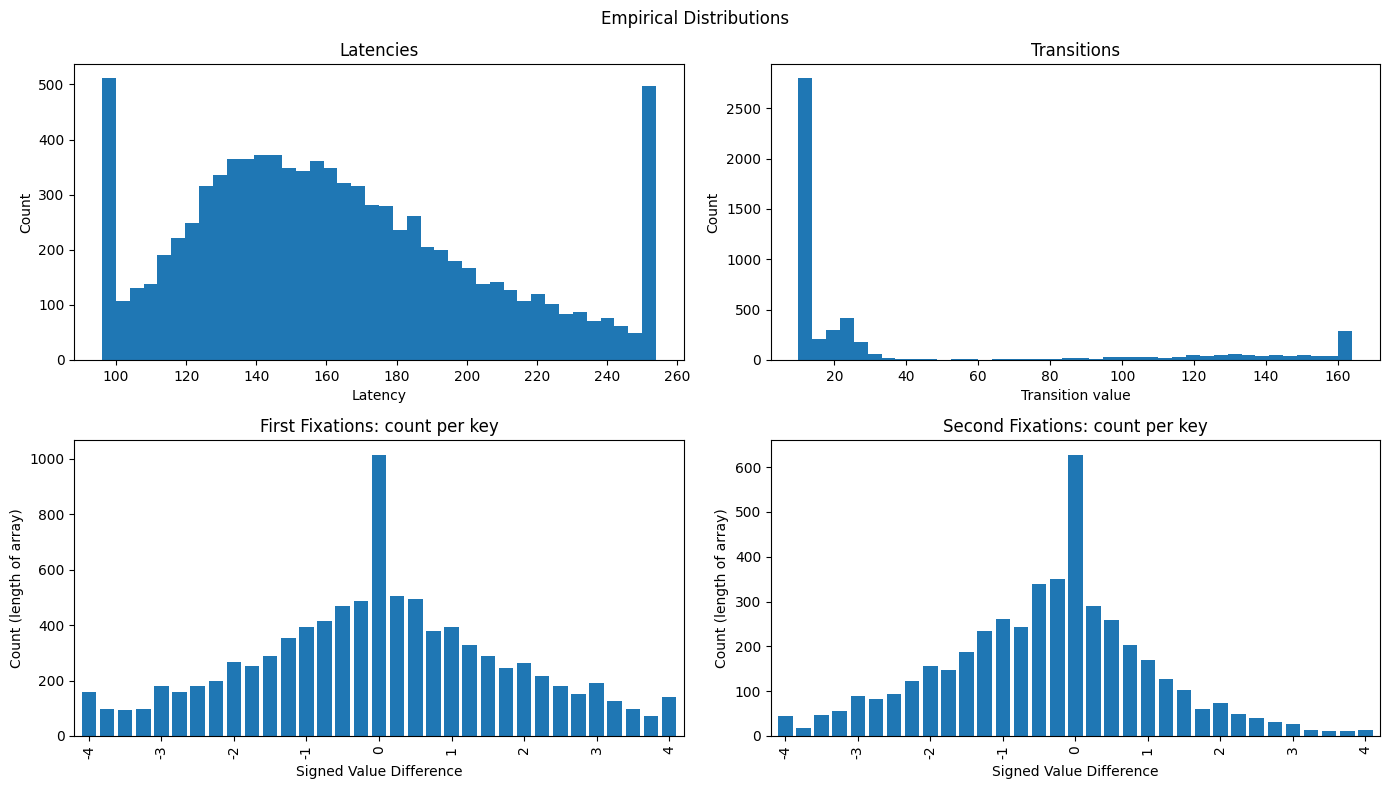

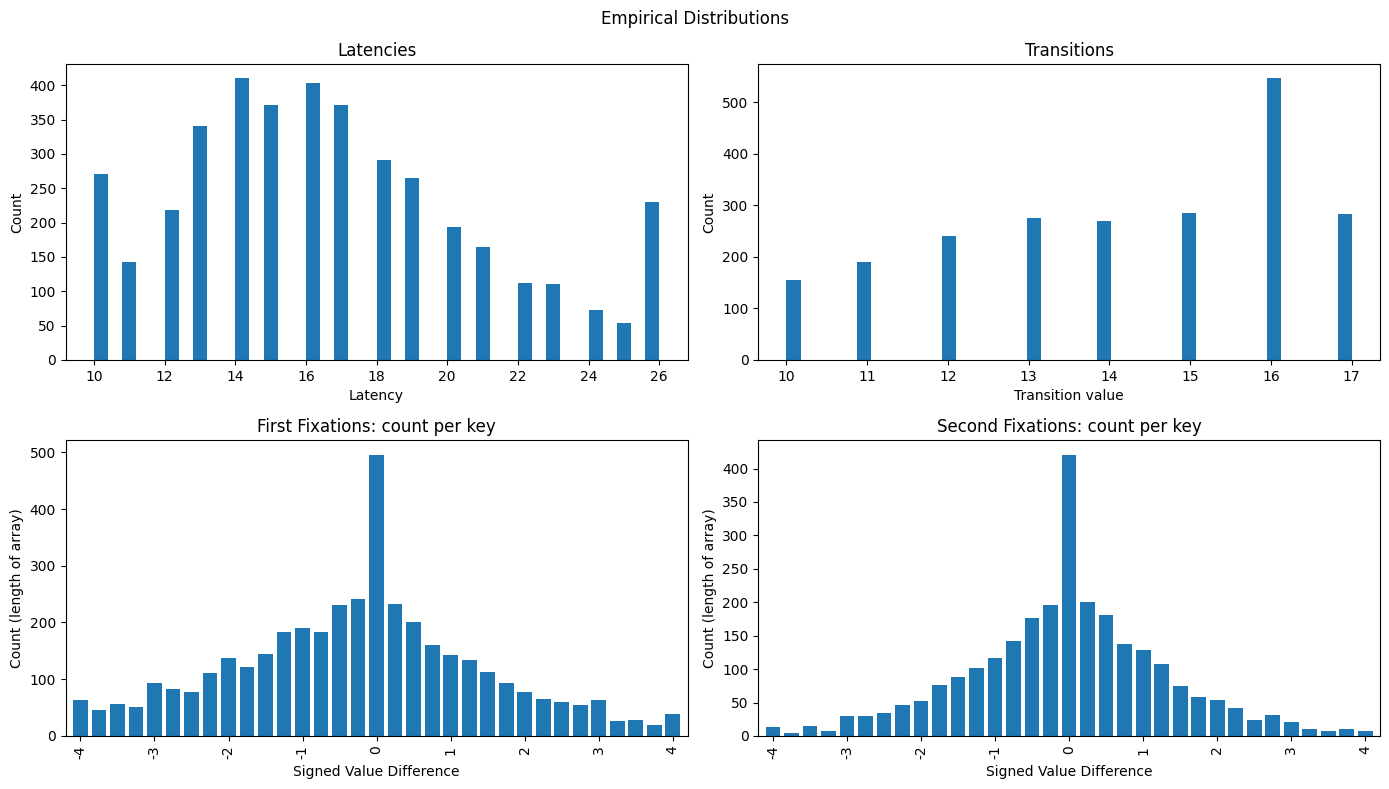

In [9]:
fig, axes = plot_empirical_distributions(empirical_distributions, tick_every=4)
plt.show()
fig, axes = plot_empirical_distributions(simulated_empirical_distributions, tick_every=4)
plt.show()

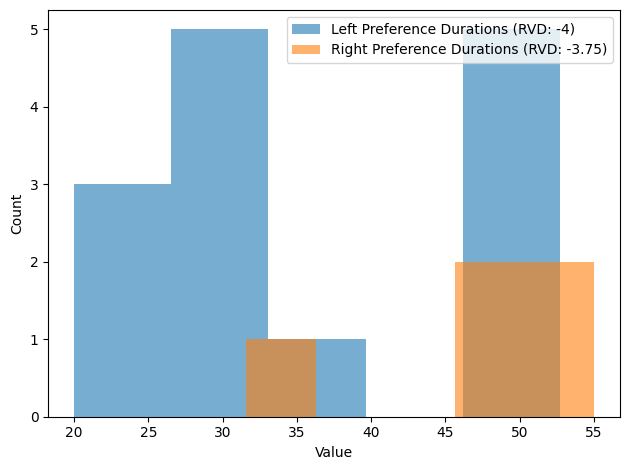

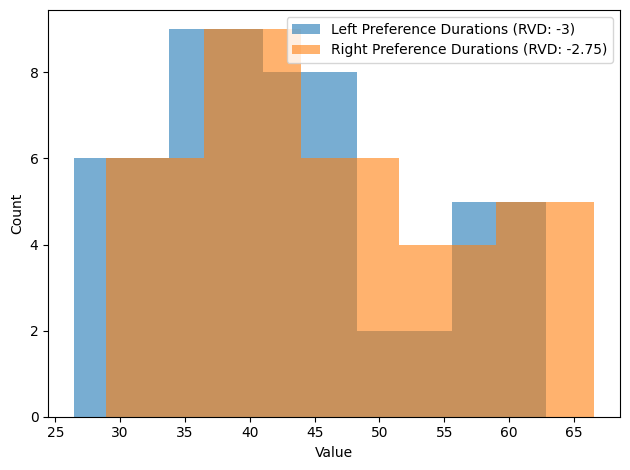

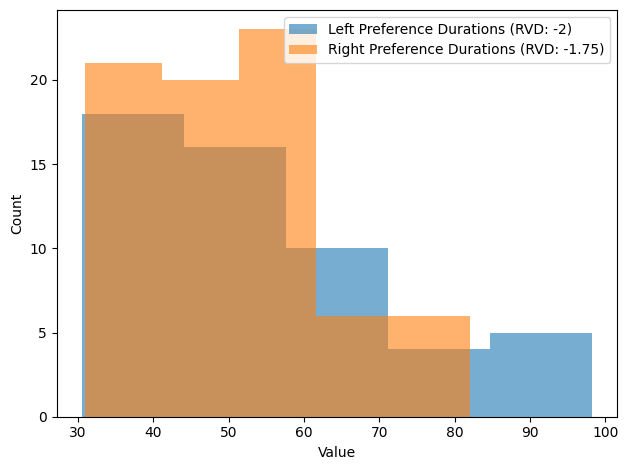

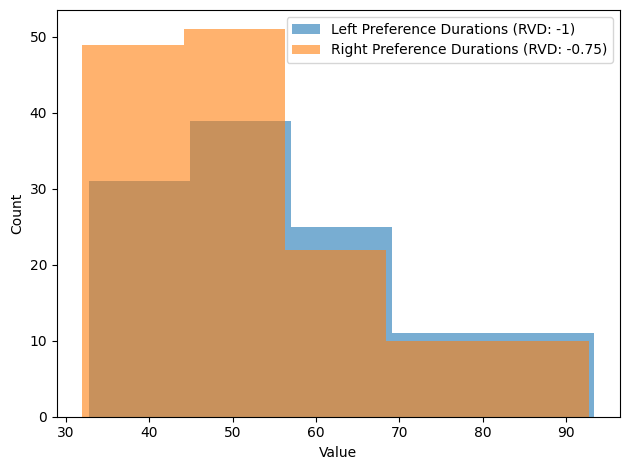

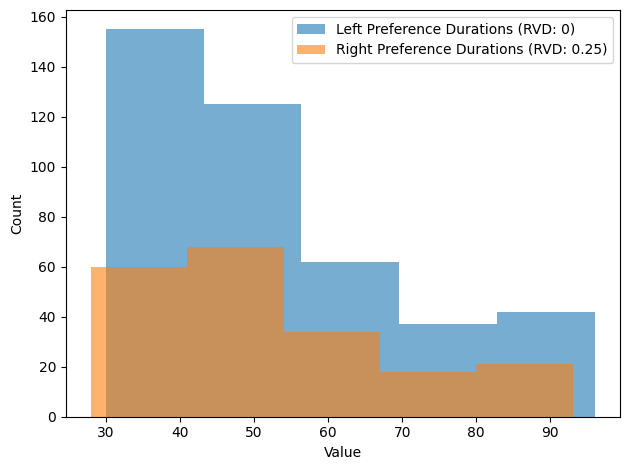

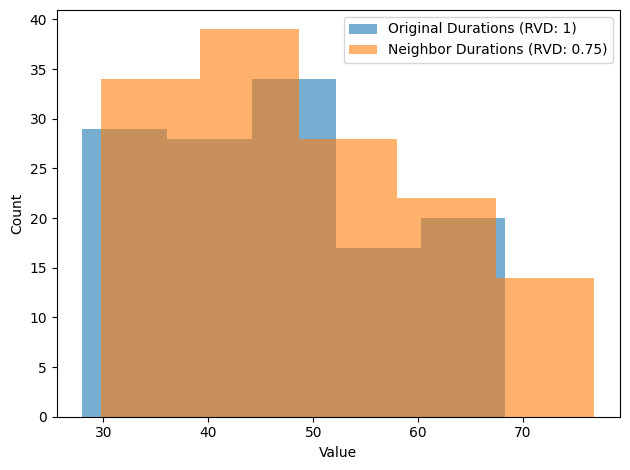

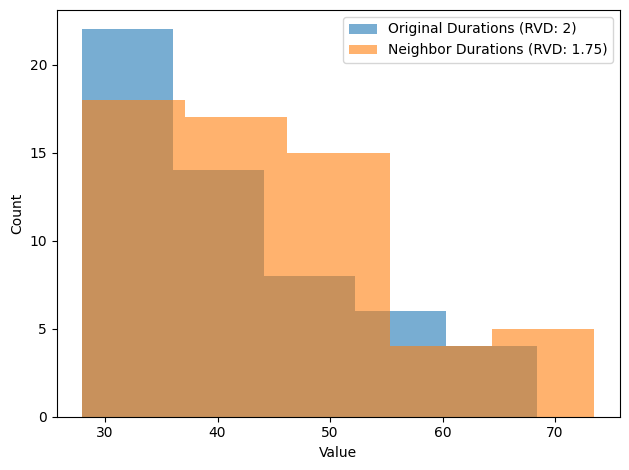

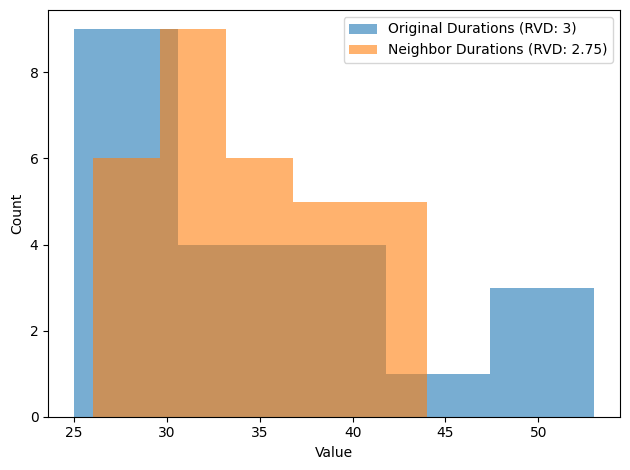

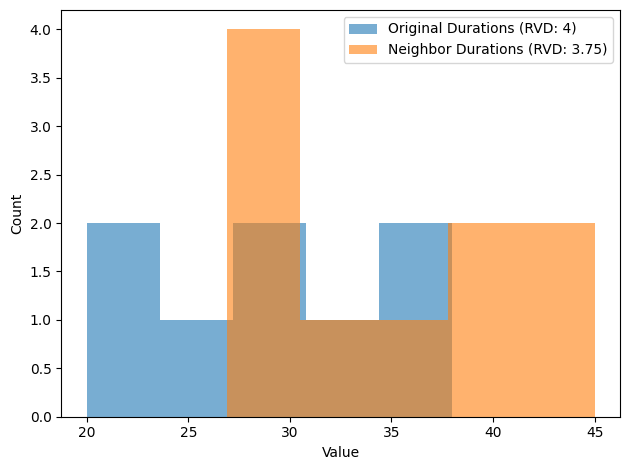

In [11]:
for i in range(-4, 5):
    if i <= 0:
        overlay_histograms(
            simulated_empirical_distributions['fixations'][2][i],
            simulated_empirical_distributions['fixations'][2][i+0.25],
            bins=5,
            label_a=f"Left Preference Durations (RVD: {i})",
            label_b=f"Right Preference Durations (RVD: {i+0.25})",
            density=False
        )
    else:
        overlay_histograms(
            simulated_empirical_distributions['fixations'][2][i],
            simulated_empirical_distributions['fixations'][2][i-0.25],
            bins=5,
            label_a=f"Original Durations (RVD: {i})",
            label_b=f"Neighbor Durations (RVD: {i-0.25})",
            density=False
        )

### Comparing model-free analysis

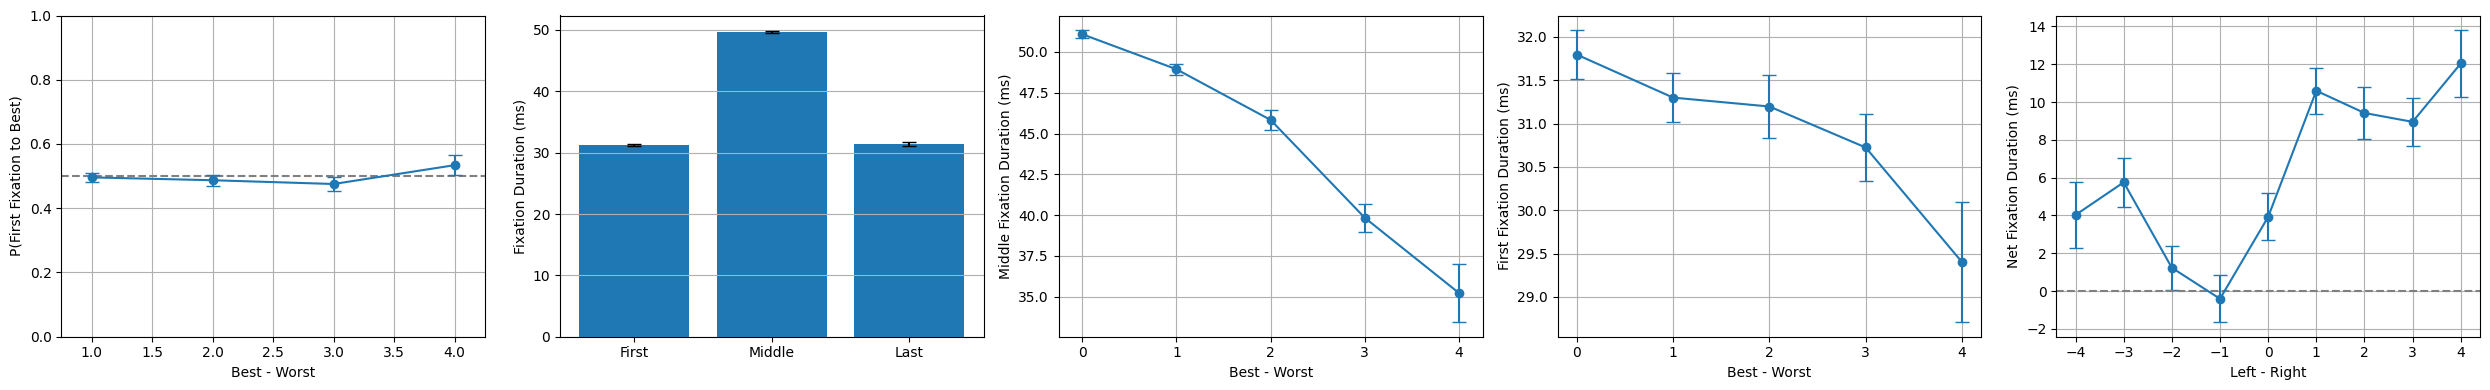

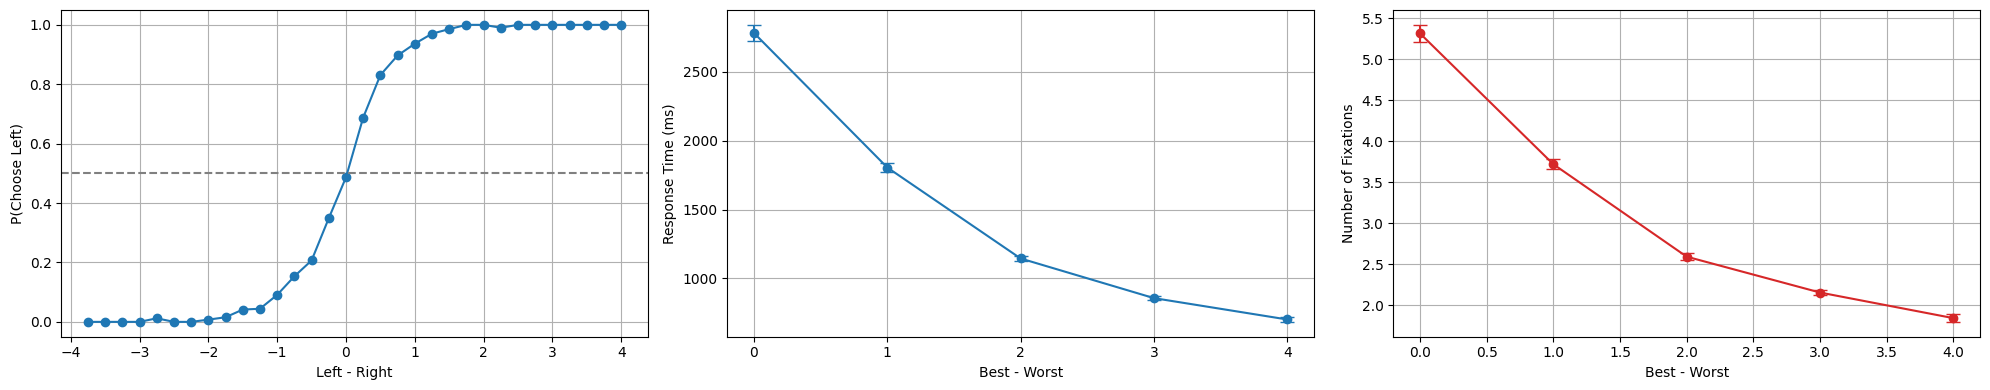

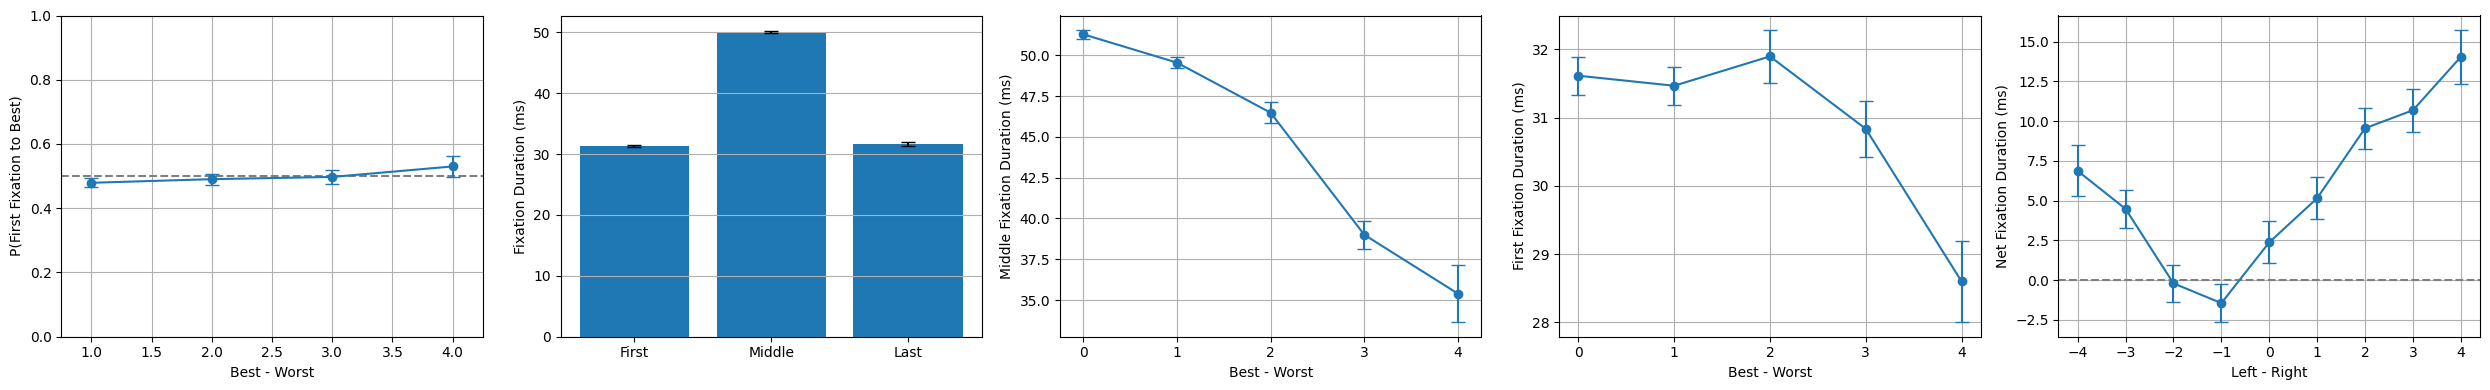

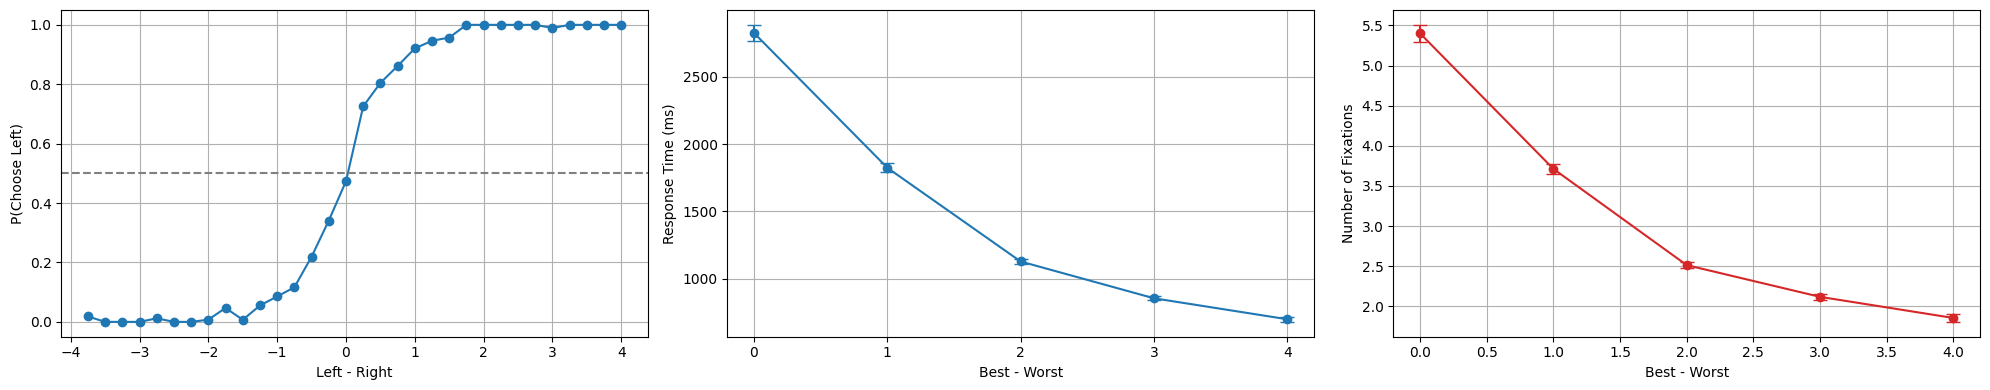

In [18]:
from pyddm.preprocessing.dataset import rasterize_data
from mfa import plot_basic_psychometrics, plot_fixation_properties

rasterized_results = rasterize_data(results_df, subject_col='sub_id', trial_col='trial', seq_col='fixation')
rasterized_results['fix_dur'] = rasterized_results.apply(
    lambda r: r['fix_end'] - r['fix_start'],
    axis=1
)

rasterized_results['fix_num'] = (
    rasterized_results
    .groupby(['sub_id', 'trial'])
    .cumcount() + 1
)

rasterized_results['fix_num_rev'] = (
    rasterized_results
    .groupby(['sub_id', 'trial'])
    .cumcount(ascending=False) + 1
)

rasterized_interpolated_results = rasterize_data(interpolate_results_df, subject_col='sub_id', trial_col='trial', seq_col='fixation')
rasterized_interpolated_results['fix_dur'] = rasterized_interpolated_results.apply(
    lambda r: r['fix_end'] - r['fix_start'],
    axis=1
)

rasterized_interpolated_results['fix_num'] = (
    rasterized_interpolated_results
    .groupby(['sub_id', 'trial'])
    .cumcount() + 1
)

rasterized_interpolated_results['fix_num_rev'] = (
    rasterized_interpolated_results
    .groupby(['sub_id', 'trial'])
    .cumcount(ascending=False) + 1
)

plot_fixation_properties(rasterized_results)
plot_basic_psychometrics(rasterized_results)

plot_fixation_properties(rasterized_interpolated_results)
plot_basic_psychometrics(rasterized_interpolated_results)

Notice that the fifth fixation properties graph is a bit smoother with interpolation than with pooling. This decision should be futher reviewed.